# Confusion Matrix Tables
Compares **structure-based** vs **sequence-based** HMM at optimal thresholds.

Files expected in `Data/Processed/`:
- `struct_set_1.class`, `struct_set_2.class`
- `seq_set_1.class`, `seq_set_2.class`

In [1]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, FancyBboxPatch
import numpy as np

BASE = '../Data/Processed'

def parse_class(filepath):
    data = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            data.append((int(parts[1]), float(parts[2])))
    return data

def confusion_at_threshold(data, t):
    TP = FP = TN = FN = 0
    for y, e in data:
        pred = 1 if e <= t else 0
        if pred == 1 and y == 1: TP += 1
        elif pred == 1 and y == 0: FP += 1
        elif pred == 0 and y == 0: TN += 1
        else: FN += 1
    return TN, FP, FN, TP

def mcc(TN, FP, FN, TP):
    num = TP*TN - FP*FN
    den = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return num/den if den != 0 else 0.0

def tpr(TN, FP, FN, TP):
    return TP/(TP+FN) if (TP+FN) > 0 else 0.0

def ppv(TN, FP, FN, TP):
    return TP/(TP+FP) if (TP+FP) > 0 else 0.0

# Load
struct1 = parse_class(f'{BASE}/struct_set_1.class')
struct2 = parse_class(f'{BASE}/struct_set_2.class')
seq1    = parse_class(f'{BASE}/seq_set_1.class')
seq2    = parse_class(f'{BASE}/seq_set_2.class')

# Optimal threshold
THRESHOLD = 1e-5

results = {
    ('Structure-based', 'Fold 1'): confusion_at_threshold(struct1, THRESHOLD),
    ('Structure-based', 'Fold 2'): confusion_at_threshold(struct2, THRESHOLD),
    ('Sequence-based',  'Fold 1'): confusion_at_threshold(seq1, THRESHOLD),
    ('Sequence-based',  'Fold 2'): confusion_at_threshold(seq2, THRESHOLD),
}

print(f'=== Results at threshold {THRESHOLD} ===\n')
for (model, fold), (TN, FP, FN, TP) in results.items():
    print(f'{model} | {fold}:')
    print(f'  TN={TN:,}  FP={FP}  FN={FN}  TP={TP}')
    print(f'  MCC={mcc(TN,FP,FN,TP):.4f}  TPR={tpr(TN,FP,FN,TP):.4f}  PPV={ppv(TN,FP,FN,TP):.4f}')
    print()

=== Results at threshold 1e-05 ===

Structure-based | Fold 1:
  TN=287,115  FP=0  FN=1  TP=105
  MCC=0.9953  TPR=0.9906  PPV=1.0000

Structure-based | Fold 2:
  TN=287,113  FP=1  FN=3  TP=102
  MCC=0.9808  TPR=0.9714  PPV=0.9903

Sequence-based | Fold 1:
  TN=287,115  FP=0  FN=1  TP=105
  MCC=0.9953  TPR=0.9906  PPV=1.0000

Sequence-based | Fold 2:
  TN=287,113  FP=1  FN=3  TP=102
  MCC=0.9808  TPR=0.9714  PPV=0.9903



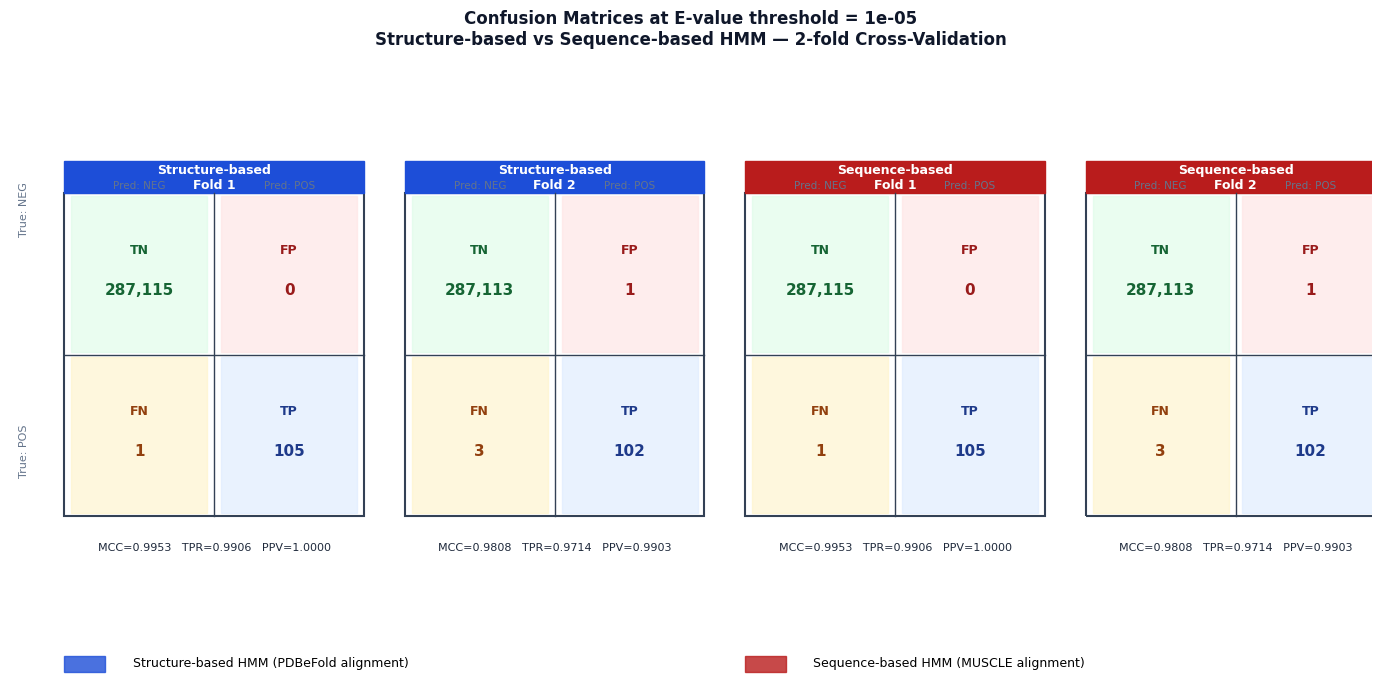

Saved: Figure_Confusion_Matrices.png


In [2]:
def draw_confusion_box(ax, x0, y0, w, h, model_name, fold_name, TN, FP, FN, TP, color):
    """Draw a single confusion matrix box"""
    # Header
    ax.add_patch(Rectangle((x0, y0+h), w, 0.06, color=color, zorder=2))
    ax.text(x0 + w/2, y0+h+0.03, f'{model_name}\n{fold_name}',
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='white', zorder=3)

    # Outer box
    ax.add_patch(Rectangle((x0, y0), w, h, fill=False, linewidth=1.5, edgecolor='#334155'))

    # Dividers
    ax.plot([x0+w/2, x0+w/2], [y0, y0+h], color='#334155', linewidth=1.0)
    ax.plot([x0, x0+w], [y0+h/2, y0+h/2], color='#334155', linewidth=1.0)

    # Predicted label headers
    ax.text(x0 + w*0.25, y0+h+0.005, 'Pred: NEG', ha='center', va='bottom', fontsize=7.5, color='#64748b')
    ax.text(x0 + w*0.75, y0+h+0.005, 'Pred: POS', ha='center', va='bottom', fontsize=7.5, color='#64748b')

    # Cell labels
    cell_data = [
        (x0+w*0.25, y0+h*0.75, 'TN', f'{TN:,}',  '#166534', '#dcfce7'),
        (x0+w*0.75, y0+h*0.75, 'FP', f'{FP}',    '#991b1b', '#fee2e2'),
        (x0+w*0.25, y0+h*0.25, 'FN', f'{FN}',    '#92400e', '#fef3c7'),
        (x0+w*0.75, y0+h*0.25, 'TP', f'{TP}',    '#1e3a8a', '#dbeafe'),
    ]
    cw, ch = w/2, h/2
    offsets = [(x0, y0+h/2), (x0+w/2, y0+h/2), (x0, y0), (x0+w/2, y0)]
    for (cx, cy, lbl, val, tc, bg), (ox, oy) in zip(cell_data, offsets):
        ax.add_patch(Rectangle((ox+0.005, oy+0.005), cw-0.01, ch-0.01,
                               color=bg, alpha=0.6, zorder=1))
        ax.text(cx, cy+ch*0.15, lbl, ha='center', va='center',
                fontsize=9, color=tc, fontweight='bold')
        ax.text(cx, cy-ch*0.10, val, ha='center', va='center',
                fontsize=11, color=tc, fontweight='bold')

    # Metrics below box
    m = mcc(TN, FP, FN, TP)
    t = tpr(TN, FP, FN, TP)
    p = ppv(TN, FP, FN, TP)
    ax.text(x0+w/2, y0-0.05,
            f'MCC={m:.4f}   TPR={t:.4f}   PPV={p:.4f}',
            ha='center', va='top', fontsize=8, color='#1e293b')

# Figure with 4 confusion matrices (2 models × 2 folds)
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 1)
ax.set_ylim(-0.15, 1.05)
ax.set_axis_off()

# Title
ax.text(0.5, 1.02,
        f'Confusion Matrices at E-value threshold = {THRESHOLD:.0e}\n'
        f'Structure-based vs Sequence-based HMM — 2-fold Cross-Validation',
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#0f172a')

# Row labels
ax.text(0.01, 0.72, 'True: NEG', ha='center', va='center', fontsize=8,
        color='#64748b', rotation=90)
ax.text(0.01, 0.27, 'True: POS', ha='center', va='center', fontsize=8,
        color='#64748b', rotation=90)

positions = [
    (('Structure-based', 'Fold 1'), 0.04,  0.15, 0.22, 0.60, '#1d4ed8'),
    (('Structure-based', 'Fold 2'), 0.29,  0.15, 0.22, 0.60, '#1d4ed8'),
    (('Sequence-based',  'Fold 1'), 0.54,  0.15, 0.22, 0.60, '#b91c1c'),
    (('Sequence-based',  'Fold 2'), 0.79,  0.15, 0.22, 0.60, '#b91c1c'),
]

for (model, fold), x0, y0, w, h, color in positions:
    TN, FP, FN, TP = results[(model, fold)]
    draw_confusion_box(ax, x0, y0, w, h, model, fold, TN, FP, FN, TP, color)

# Legend
ax.add_patch(Rectangle((0.04, -0.14), 0.03, 0.03, color='#1d4ed8', alpha=0.8))
ax.text(0.09, -0.125, 'Structure-based HMM (PDBeFold alignment)', va='center', fontsize=9)
ax.add_patch(Rectangle((0.54, -0.14), 0.03, 0.03, color='#b91c1c', alpha=0.8))
ax.text(0.59, -0.125, 'Sequence-based HMM (MUSCLE alignment)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Figure_Confusion_Matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure_Confusion_Matrices.png')